In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%matplotlib inline
# %matplotlib widget

(-0.4, 0.4)

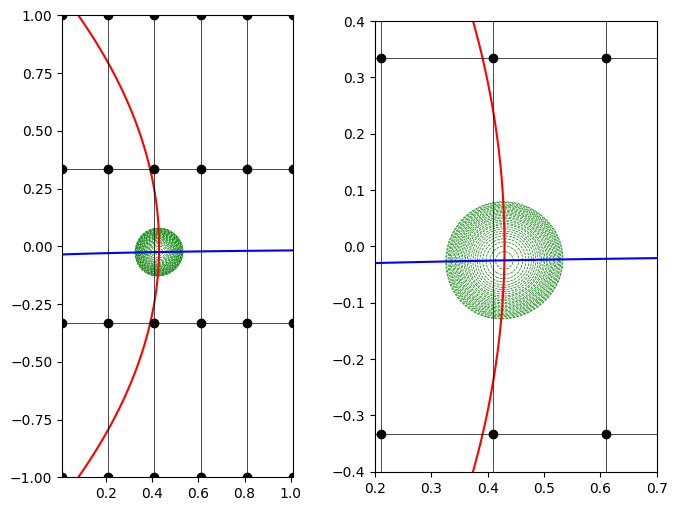

In [3]:
# Create a large grid so that we can "see" the function
n_r = 181
n_z = 261
r = np.linspace(0.01, 1.01, n_r)
z = np.linspace(-1.0, 1.0, n_z)

# Create a smaller grid for the testing
n_test_r = 6
n_test_z = 4
test_r = np.linspace(0.01, 1.01, n_test_r)
test_z = np.linspace(-1.0, 1.0, n_test_z)
test_grid_r, test_grid_z = np.meshgrid(test_r, test_z)
test_flat_r = test_grid_r.flatten()
test_flat_z = test_grid_z.flatten()

psi = np.zeros((n_z, n_r))
d_psi_d_r = np.zeros((n_z, n_r))
d_psi_d_z = np.zeros((n_z, n_r))

vertical_curvature = 0.35

for i in range(n_z):
    for j in range(n_r):
        r_center = 0.43 - vertical_curvature * z[i]**2
        psi[i, j] = -(r[j] - r_center)**2 - (z[i] + 25e-3)**2
        d_psi_d_r[i, j] = -2.0 * (r[j] - r_center)
        d_psi_d_z[i, j] = -2.0 * (r[j] - r_center) * 2.0 * vertical_curvature * z[i] - 2.0 * (z[i] + 25e-3)

psi_near_magnetic_axis = np.sort(psi, axis=None)[-800:][::-1]
top_10_psi = np.flip(psi_near_magnetic_axis)[::30]

fig, ax = plt.subplots(1, 2, figsize=(8, 6))

for ax_local in ax:
    ax_local.contour(r, z, psi, levels=top_10_psi, colors='green', linewidths=0.5)
    ax_local.contour(r, z, d_psi_d_r, levels=[0.0], colors='red')
    ax_local.contour(r, z, d_psi_d_z, levels=[0.0], colors='blue')
    ax_local.plot(test_flat_r, test_flat_z, marker="o", linestyle='None', color='black')
    for i_r in range(n_test_r):
        ax_local.plot(test_r[i_r] * np.ones(n_test_z), test_z, linestyle='-', color='black', linewidth=0.5)
    for i_z in range(n_test_z):
        ax_local.plot(test_r, test_z[i_z] * np.ones(n_test_r), linestyle='-', color='black', linewidth=0.5)
    ax_local.set_aspect('equal')

# Zoom in on the right plot
ax[1].set_xlim(0.2, 0.7)
ax[1].set_ylim(-0.4, 0.4)